cloud_model4就有对云模型和双云模型拟合的具体公式和拟合代码， 但是这个玩意挺随机的

In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import glob
from scipy.io import readsav
from functools import partial

#数据准备
dir=r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
lam = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam=lam[44:96]#序号50-90是从Ha线性蓝翼到红翼，线心的±1A
I0=rsm[1].data[44:96,797:826,1540:1569].mean(axis=(1,2))

In [2]:
def single_cloud(lam,S,tau0,v,W,I0):
    lam0=6562.8
    c=299792
    tau=tau0*np.exp(-((lam-lam0-v*lam0/c)**2)/W**2)
    I=I0*np.exp(-tau)+S*(1-np.exp(-tau))
    return I

S=394.77, tau0=1.20, v=18.28, W=0.89


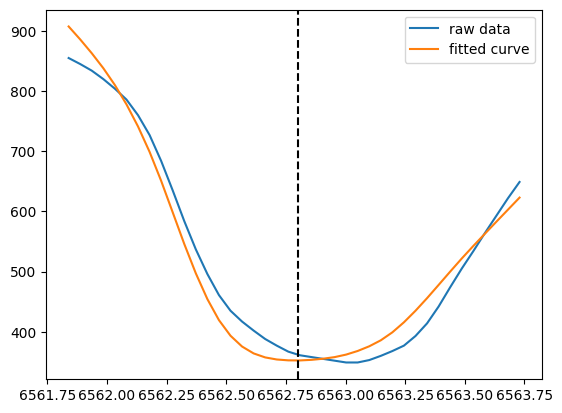

In [12]:
I=rsm[1].data[50:90,792,1521]
#初值
paras=np.zeros((3,4))
#第0列是S_initial,min,max
paras[0,0],paras[1,0],paras[2,0]=np.mean(I0),0,20000
#第1列是\tau0_initial,min,max
paras[0,1],paras[1,1],paras[2,1]=0.2,0.001,100
#第2列是v_initial,min,max
paras[0,2],paras[1,2],paras[2,2]=-20,-100,200
#第3列是多普勒展宽W
paras[0,3],paras[1,3],paras[2,3]=0.5,0.01,10

#曲线拟合
single_cloud_par=partial(single_cloud,I0=I0)
popt,pcov=curve_fit(single_cloud_par,lam,I,p0=paras[0,:],
                    bounds=(paras[1,:],paras[2,:]),maxfev=2000)

#输出拟合结果
S_fit,tau0_fit,v_fit,W_fit=popt
print('S={:.2f}, tau0={:.2f}, v={:.2f}, W={:.2f}'.format(S_fit,tau0_fit,v_fit,W_fit))

#画图看拟合效果
plt.plot(lam,I,label='raw data')
plt.plot(lam,single_cloud_par(lam,*popt),label='fitted curve')
plt.axvline(x=6562.8,linestyle='--',color='black')
plt.legend()

In [2]:
def double_cloud(lam,SL,SU,tau0L,tau0U,vL,vU,WL,WU,I0):
    lam0=6562.8
    c=299790
    tauL=tau0L*np.exp(-((lam-lam0-vL*lam0/c)**2)/WL**2)
    tauU=tau0U*np.exp(-((lam-lam0-vU*lam0/c)**2)/WU**2)
    I=I0*np.exp(-(tauL+tauU))+SL*(1-np.exp(-tauL))*np.exp(-tauU)+SU*(1-np.exp(-tauU))
    return I

对初值非常敏感啊

SL=0.00,初值是684.17,范围是[0.00,20000.00], SU=662.13,初值是684.17,范围是[0.00,20000.00]
tau0L=0.57,初值是0.20,范围是[0.00,100.00], tau0U=0.66,初值是0.20,范围是[0.00,100.00]
vL=-14.85,初值是-11.00,范围是[-100.00,100.00], vU=-10.25,初值是-13.00,范围是[-150.00,100.00]
WL=1.13,初值是0.50,范围是[0.01,10.00], WU=0.82,初值是0.50,范围是[0.01,10.00]
拟合误差: 1390.9491654192639


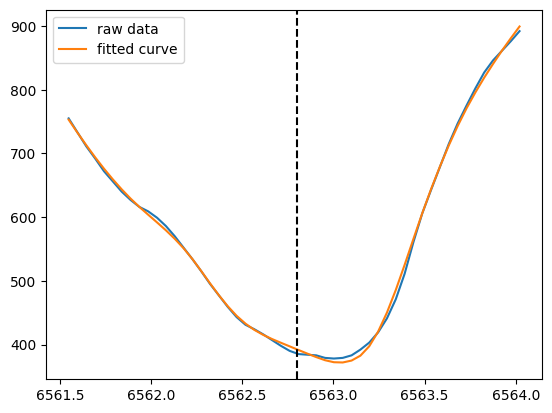

In [7]:
#I=rsm[1].data[50:90,795,1521]
I=rsm[1].data[44:96,794,1518]
#初值
paras2=np.zeros((3,8))
#第0列是SL_initial,min,max
paras2[0,0],paras2[1,0],paras2[2,0]=np.mean(I0),0,20000
#第1列是SU_initial,min,max
paras2[0,1],paras2[1,1],paras2[2,1]=np.mean(I0),0,20000
#第2列是\tau0L_initial,min,max
paras2[0,2],paras2[1,2],paras2[2,2]=0.2,0.001,100
#第3列是\tau0U_initial,min,max
paras2[0,3],paras2[1,3],paras2[2,3]=0.2,0.001,100
#第4列是vL_initial,min,max
paras2[0,4],paras2[1,4],paras2[2,4]=-11,-100,100
#第5列是vU_initial,min,max
paras2[0,5],paras2[1,5],paras2[2,5]=-13,-150,100
#第6列是多普勒展宽WL
paras2[0,6],paras2[1,6],paras2[2,6]=0.5,0.01,10
#第7列是多普勒展宽WU
paras2[0,7],paras2[1,7],paras2[2,7]=0.5,0.01,10


#曲线拟合
double_cloud_par=partial(double_cloud,I0=I0)
popt2,pcov2=curve_fit(double_cloud_par,lam,I,p0=paras2[0,:],
                    bounds=(paras2[1,:],paras2[2,:]),maxfev=2000)

#输出拟合结果
SL_fit,SU_fit,tau0L_fit,tau0U_fit,vL_fit,vU_fit,WL_fit,WU_fit=popt2
print('SL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], SU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(SL_fit,paras2[0,0],paras2[1,0],paras2[2,0],SU_fit,paras2[0,1],paras2[1,1],paras2[2,1]))
print('tau0L={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], tau0U={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(tau0L_fit,paras2[0,2],paras2[1,2],paras2[2,2],tau0U_fit,paras2[0,3],paras2[1,3],paras2[2,3]))
print('vL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], vU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(vL_fit,paras2[0,4],paras2[1,4],paras2[2,4],vU_fit,paras2[0,5],paras2[1,5],paras2[2,5]))
print('WL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], WU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(WL_fit,paras2[0,6],paras2[1,6],paras2[2,6],WU_fit,paras2[0,7],paras2[1,7],paras2[2,7]))

#画图看拟合效果
plt.plot(lam,I,label='raw data')
plt.plot(lam,double_cloud_par(lam,*popt2),label='fitted curve')
plt.axvline(x=6562.8,linestyle='--',color='black')
plt.legend()

y_fit=double_cloud_par(lam,*popt2)
print('拟合误差:',np.sum((I-y_fit)**2))

SL=7.62,初值是684.17,范围是[0.00,20000.00], SU=614.94,初值是684.17,范围是[0.00,20000.00]
tau0L=1.14,初值是0.20,范围是[0.00,100.00], tau0U=0.85,初值是0.20,范围是[0.00,100.00]
vL=15.76,初值是10.00,范围是[-150.00,100.00], vU=100.00,初值是-10.00,范围是[-100.00,100.00]
WL=0.51,初值是0.50,范围是[0.01,10.00], WU=3.78,初值是0.50,范围是[0.01,10.00]
拟合误差: 56.35185861249628


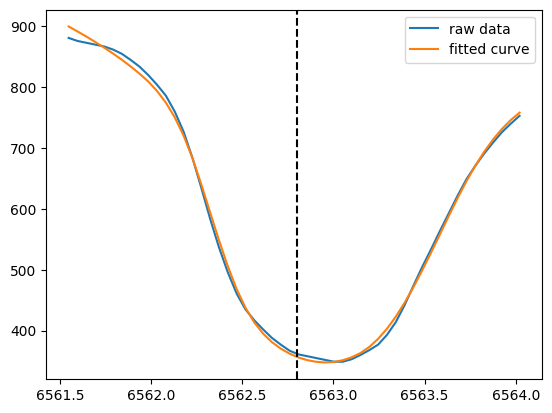

In [7]:
#I=rsm[1].data[50:90,795,1521]
I=rsm[1].data[44:96,792,1521]
#初值
paras2=np.zeros((3,8))
#第0列是SL_initial,min,max
paras2[0,0],paras2[1,0],paras2[2,0]=np.mean(I0),0,20000
#第1列是SU_initial,min,max
paras2[0,1],paras2[1,1],paras2[2,1]=np.mean(I0),0,20000
#第2列是\tau0L_initial,min,max
paras2[0,2],paras2[1,2],paras2[2,2]=0.2,0.001,100
#第3列是\tau0U_initial,min,max
paras2[0,3],paras2[1,3],paras2[2,3]=0.2,0.001,100
#第4列是vL_initial,min,max
paras2[0,4],paras2[1,4],paras2[2,4]=10,-150,100
#第5列是vU_initial,min,max
paras2[0,5],paras2[1,5],paras2[2,5]=-10,-100,100
#第6列是多普勒展宽WL
paras2[0,6],paras2[1,6],paras2[2,6]=0.5,0.01,10
#第7列是多普勒展宽WU
paras2[0,7],paras2[1,7],paras2[2,7]=0.5,0.01,10


#曲线拟合
double_cloud_par=partial(double_cloud,I0=I0)
popt2,pcov2=curve_fit(double_cloud_par,lam,I,p0=paras2[0,:],
                    bounds=(paras2[1,:],paras2[2,:]),maxfev=2000)

#输出拟合结果
SL_fit,SU_fit,tau0L_fit,tau0U_fit,vL_fit,vU_fit,WL_fit,WU_fit=popt2
print('SL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], SU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(SL_fit,paras2[0,0],paras2[1,0],paras2[2,0],SU_fit,paras2[0,1],paras2[1,1],paras2[2,1]))
print('tau0L={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], tau0U={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(tau0L_fit,paras2[0,2],paras2[1,2],paras2[2,2],tau0U_fit,paras2[0,3],paras2[1,3],paras2[2,3]))
print('vL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], vU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(vL_fit,paras2[0,4],paras2[1,4],paras2[2,4],vU_fit,paras2[0,5],paras2[1,5],paras2[2,5]))
print('WL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], WU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(WL_fit,paras2[0,6],paras2[1,6],paras2[2,6],WU_fit,paras2[0,7],paras2[1,7],paras2[2,7]))

#画图看拟合效果
plt.plot(lam,I,label='raw data')
plt.plot(lam,double_cloud_par(lam,*popt2),label='fitted curve')
plt.axvline(x=6562.8,linestyle='--',color='black')
plt.legend()
y_fit=double_cloud_par(lam,*popt2)
print('拟合误差:',np.sum((I-y_fit)**2)/len(I))

SL=0.00,初值是593.59,范围是[0.00,20000.00], SU=856.92,初值是593.59,范围是[0.00,20000.00]
tau0L=2.02,初值是0.20,范围是[0.00,100.00], tau0U=0.56,初值是0.20,范围是[0.00,100.00]
vL=4.94,初值是10.00,范围是[0.00,100.00], vU=-100.00,初值是-10.00,范围是[-100.00,0.00]
WL=0.56,初值是0.50,范围是[0.01,10.00], WU=6.84,初值是0.50,范围是[0.01,10.00]


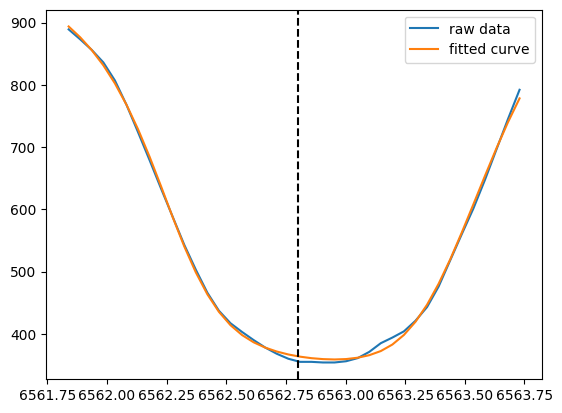

In [5]:
#I=rsm[1].data[50:90,795,1521]
I=rsm[1].data[50:90,791,1518]
#初值
paras2=np.zeros((3,8))
#第0列是SL_initial,min,max
paras2[0,0],paras2[1,0],paras2[2,0]=np.mean(I0),0,20000
#第1列是SU_initial,min,max
paras2[0,1],paras2[1,1],paras2[2,1]=np.mean(I0),0,20000
#第2列是\tau0L_initial,min,max
paras2[0,2],paras2[1,2],paras2[2,2]=0.2,0.001,100
#第3列是\tau0U_initial,min,max
paras2[0,3],paras2[1,3],paras2[2,3]=0.2,0.001,100
#第4列是vL_initial,min,max
paras2[0,4],paras2[1,4],paras2[2,4]=10,0,100
#第5列是vU_initial,min,max
paras2[0,5],paras2[1,5],paras2[2,5]=-10,-100,0
#第6列是多普勒展宽WL
paras2[0,6],paras2[1,6],paras2[2,6]=0.5,0.01,10
#第7列是多普勒展宽WU
paras2[0,7],paras2[1,7],paras2[2,7]=0.5,0.01,10


#曲线拟合
double_cloud_par=partial(double_cloud,I0=I0)
popt2,pcov2=curve_fit(double_cloud_par,lam,I,p0=paras2[0,:],
                    bounds=(paras2[1,:],paras2[2,:]),maxfev=2000)

#输出拟合结果
SL_fit,SU_fit,tau0L_fit,tau0U_fit,vL_fit,vU_fit,WL_fit,WU_fit=popt2
print('SL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], SU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(SL_fit,paras2[0,0],paras2[1,0],paras2[2,0],SU_fit,paras2[0,1],paras2[1,1],paras2[2,1]))
print('tau0L={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], tau0U={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(tau0L_fit,paras2[0,2],paras2[1,2],paras2[2,2],tau0U_fit,paras2[0,3],paras2[1,3],paras2[2,3]))
print('vL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], vU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(vL_fit,paras2[0,4],paras2[1,4],paras2[2,4],vU_fit,paras2[0,5],paras2[1,5],paras2[2,5]))
print('WL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], WU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(WL_fit,paras2[0,6],paras2[1,6],paras2[2,6],WU_fit,paras2[0,7],paras2[1,7],paras2[2,7]))

#画图看拟合效果
plt.plot(lam,I,label='raw data')
plt.plot(lam,double_cloud_par(lam,*popt2),label='fitted curve')
plt.axvline(x=6562.8,linestyle='--',color='black')
plt.legend()

SL=0.00,初值是593.59,范围是[0.00,20000.00], SU=857.74,初值是593.59,范围是[0.00,20000.00]
tau0L=2.02,初值是0.20,范围是[0.00,100.00], tau0U=0.59,初值是0.20,范围是[0.00,100.00]
vL=4.93,初值是10.00,范围是[0.00,100.00], vU=-150.00,初值是-10.00,范围是[-150.00,0.00]
WL=0.56,初值是0.50,范围是[0.01,10.00], WU=8.29,初值是0.50,范围是[0.01,10.00]


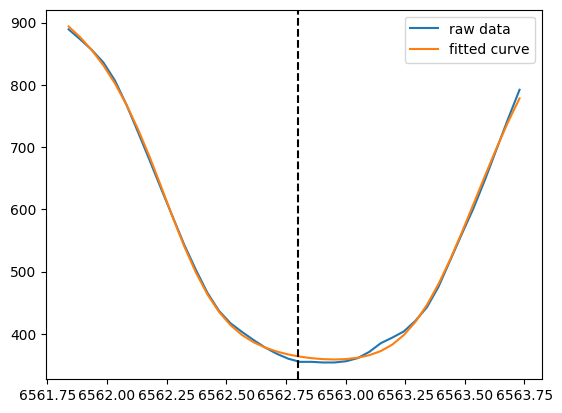

In [8]:
#I=rsm[1].data[50:90,795,1521]
I=rsm[1].data[50:90,791,1518]
#初值
paras2=np.zeros((3,8))
#第0列是SL_initial,min,max
paras2[0,0],paras2[1,0],paras2[2,0]=np.mean(I0),0,20000
#第1列是SU_initial,min,max
paras2[0,1],paras2[1,1],paras2[2,1]=np.mean(I0),0,20000
#第2列是\tau0L_initial,min,max
paras2[0,2],paras2[1,2],paras2[2,2]=0.2,0.001,100
#第3列是\tau0U_initial,min,max
paras2[0,3],paras2[1,3],paras2[2,3]=0.2,0.001,100
#第4列是vL_initial,min,max
paras2[0,4],paras2[1,4],paras2[2,4]=10,0,100
#第5列是vU_initial,min,max
paras2[0,5],paras2[1,5],paras2[2,5]=-10,-150,0
#第6列是多普勒展宽WL
paras2[0,6],paras2[1,6],paras2[2,6]=0.5,0.01,10
#第7列是多普勒展宽WU
paras2[0,7],paras2[1,7],paras2[2,7]=0.5,0.01,10


#曲线拟合
double_cloud_par=partial(double_cloud,I0=I0)
popt2,pcov2=curve_fit(double_cloud_par,lam,I,p0=paras2[0,:],
                    bounds=(paras2[1,:],paras2[2,:]),maxfev=2000)

#输出拟合结果
SL_fit,SU_fit,tau0L_fit,tau0U_fit,vL_fit,vU_fit,WL_fit,WU_fit=popt2
print('SL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], SU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(SL_fit,paras2[0,0],paras2[1,0],paras2[2,0],SU_fit,paras2[0,1],paras2[1,1],paras2[2,1]))
print('tau0L={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], tau0U={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(tau0L_fit,paras2[0,2],paras2[1,2],paras2[2,2],tau0U_fit,paras2[0,3],paras2[1,3],paras2[2,3]))
print('vL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], vU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(vL_fit,paras2[0,4],paras2[1,4],paras2[2,4],vU_fit,paras2[0,5],paras2[1,5],paras2[2,5]))
print('WL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], WU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(WL_fit,paras2[0,6],paras2[1,6],paras2[2,6],WU_fit,paras2[0,7],paras2[1,7],paras2[2,7]))

#画图看拟合效果
plt.plot(lam,I,label='raw data')
plt.plot(lam,double_cloud_par(lam,*popt2),label='fitted curve')
plt.axvline(x=6562.8,linestyle='--',color='black')
plt.legend()